# ___Data wrangling for the paper draft; with `FRED 4.0`___
--------------------------------------

In [71]:
!python --version

Python 3.14.5


The system cannot find the path specified.


In [158]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numba import njit, vectorize, float32, float64
from scipy.stats import pearsonr

In [130]:
# including all the traits Luke advised

COLLABORATION_GRADIENT_TRAITS = [
    "F00679", # RD
    "F00727", # SRL
    # "F00104", # RCT
]

CONSERVATION_GRADIENT_TRAITS = [
    "F00709", # RTD
    # "F00261", # RN
]

CHOSEN_ROOT_TRAITS = COLLABORATION_GRADIENT_TRAITS + CONSERVATION_GRADIENT_TRAITS

CHOSEN_TRAITS_DICT = {
    "F00709":  "RTD",
    # "F00261":  "RN",
    "F00679":  "RD",
    "F00727":  "SRL",
    # "F00104":  "RCT",
}

PLANT_TAXONOMY_ACCEPTED_COLUMNS = [
    "F01286", # Genus of plant according to The Plant List
    "F01287", # Species epithet of plant according to The Plant List
    "F01289", # Family of plant according to The Plant List
    "F01290"  # Order of plant.
]

BINOMINAL_NAME = ["F01286", "F01287"]
BINOMINAL_NAME_DATA_SOURCE = ["F00018", "F00019"]
ROOT_ORDER = ["F00056"]
TAXONOMY_COLUMNS_TO_CROSSCHECK = [
    "F01289", "F01290", # from FRED 4.0
    "family", "order", "group" # from the lookup table
]

FAMILIES_NOT_TO_MISS = ("Zamiaceae", "Cycadaceae", "Magnoliaceae", "Lauraceae", # generally thick rooted absorptive roots
                       "Cyperaceae", "Brassicaceae") # NM families

In [131]:
fred = pd.read_csv(r"../../data/chapter2/FRED/FRED4_Entire_Database_2026.csv", low_memory=False, header=0, skiprows=range(1, 7), encoding="latin1") # FRED 4.0
meta = pd.read_csv(r"../../data/chapter2/FRED/FRED3_Column_Definitions_2021.csv", usecols=["column_id", "name", "units"], index_col="column_id")

lookup = pd.read_csv(r"../../data/chapter2/plant_lookup.csv", low_memory=False, encoding="latin1", usecols=["genus", "apweb.family", # let's stick the the family info from APG website
                                                                                                         "order", "group"], index_col="genus").rename(mapper={"apweb.family": "family"}, axis=1) 

# thought we could use the data source's binominal names where FRED's binominal names are missing but looks like that won't help :/
# drop all the rows that do not have genus and species names
fred.dropna(subset=BINOMINAL_NAME, inplace=True)

In [83]:
meta.loc[BINOMINAL_NAME + BINOMINAL_NAME_DATA_SOURCE + CHOSEN_ROOT_TRAITS + ROOT_ORDER, :]

,name,units
column_id,,
F01286,Plant taxonomy_Accepted genus_TPL,NaN
F01287,Plant Taxonomy_Accepted species_TPL,NaN
F00018,Plant taxonomy_Genus_Data Source,NaN
F00019,Plant taxonomy_Species_Data source,NaN
F00679,Root diameter,mm
F00727,Specific root length (SRL),m/g
F00709,Root tissue density (RTD),g/cm3
F00056,Root order,NaN


In [84]:
# records with missing binominal names aren't useful to us 
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].isna().mean() # dropna(subset=BINOMINAL_NAME)

F01286    0.290605
F01287    0.314019
F01289    0.289702
F01290    0.289586
F00679    0.836937
F00727    0.832876
F00709    0.882283
dtype: float64

In [85]:
# that many records with missing binominal names???
fred.loc[:, BINOMINAL_NAME + BINOMINAL_NAME_DATA_SOURCE].isna().sum()

F01286    22539
F01287    24355
F00018    22521
F00019    23283
dtype: int64

### ___$1^{st}$ order roots___
__________________

In [7]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS + ROOT_ORDER].query(r"F00056==1")

,F01286,F01287,F01289,F01290,F00679,F00727,F00709,F00056
0,Dicranopteris,linearis,Gleicheniaceae,Gleicheniales,NaN,NaN,NaN,1.0
3,Cunninghamia,lanceolata,Cupressaceae,Cupressales,NaN,NaN,NaN,1.0
6,Magnolia,baillonii,Magnoliaceae,Magnoliales,NaN,NaN,NaN,1.0
11,Acacia,auriculiformis,Fabaceae,Fabales,NaN,NaN,NaN,1.0
15,Polyspora,axillaris,Theaceae,Ericales,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...
70350,Pinus,strobus,Pinaceae,Pinales,0.421385,17.805402,0.337226,1.0
70354,Tsuga,canadensis,Pinaceae,Pinales,0.373780,30.873103,0.204034,1.0
70358,Sciadopitys,verticillata,Sciadopityaceae,Cupressales,0.620386,29.212460,0.125136,1.0
70363,Cephalotaxus,harringtonii,Cephalotaxaceae,Cupressales,0.626291,21.950489,0.125251,1.0


In [8]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS + ROOT_ORDER].query(r"F00056==1").loc[:, BINOMINAL_NAME].drop_duplicates()

,F01286,F01287
0,Dicranopteris,linearis
3,Cunninghamia,lanceolata
6,Magnolia,baillonii
11,Acacia,auriculiformis
15,Polyspora,axillaris
...,...,...
70295,Encephalartos,gratus
70299,Zamia,lucayana
70303,Chamaecyparis,pisifera
70328,Ephedra,distachya


In [9]:
fred.loc[:, CHOSEN_ROOT_TRAITS + ROOT_ORDER].query(r"F00056==1").isna().mean().rename(index=CHOSEN_TRAITS_DICT)

RD        0.266157
SRL       0.668451
RTD       0.726195
F00056    0.000000
dtype: float64

### ___RD $\le$ 2.0 mm___
-----------------------

In [10]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"F00679 <= 2.000").dropna(subset=CHOSEN_ROOT_TRAITS)

,F01286,F01287,F01289,F01290,F00679,F00727,F00709
236,Larix,gmelinii,Pinaceae,Pinales,0.319412,32.211568,0.354286
237,Larix,gmelinii,Pinaceae,Pinales,0.411555,25.480815,0.294286
238,Larix,gmelinii,Pinaceae,Pinales,0.527621,12.980828,0.382857
239,Larix,gmelinii,Pinaceae,Pinales,0.846975,6.250067,0.334286
241,Larix,gmelinii,Pinaceae,Pinales,0.307450,34.615414,0.382857
...,...,...,...,...,...,...,...
71902,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.740062,8.685170,0.224091
71903,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.739066,8.855820,0.228155
71904,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.666566,9.584048,0.228379
71905,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.639820,10.362667,0.265331


In [11]:
# focusing on rows that have data for all the three traits
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"F00679 <= 2.000").dropna(subset=CHOSEN_ROOT_TRAITS).loc[:, BINOMINAL_NAME].drop_duplicates()

,F01286,F01287
236,Larix,gmelinii
266,Fraxinus,mandshurica
382,Populus,trichocarpa
386,Populus,tremula
827,Cinnamomum,micranthum
...,...,...
71813,Sorocea,muriculata
71814,Stachyarrhena,acuminata
71815,Trymatococcus,amazonicus
71816,Zygia,inaequalis


In [12]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"F00679 <= 2.000").dropna(subset=CHOSEN_ROOT_TRAITS).isna().mean().rename(index=CHOSEN_TRAITS_DICT)

F01286    0.0
F01287    0.0
F01289    0.0
F01290    0.0
RD        0.0
SRL       0.0
RTD       0.0
dtype: float64

In [13]:
# inspect the coverage of thick rooted families in this subset
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 2.000) and F01289.isin(@THICK_ROOTED_FAMILIES)").dropna(subset=CHOSEN_ROOT_TRAITS).drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS)

,F01286,F01287,F01289,F01290,F00679,F00727,F00709
832,Magnolia,odora,Magnoliaceae,Magnoliales,0.500991,24.405710,0.206190
7385,Magnolia,carsonii,Magnoliaceae,Magnoliales,0.743000,15.130000,0.158000
8087,Liriodendron,tulipifera,Magnoliaceae,Magnoliales,0.852750,15.188097,0.129000
8090,Magnolia,acuminata,Magnoliaceae,Magnoliales,0.982750,12.382596,0.141000
8093,Magnolia,denudata,Magnoliaceae,Magnoliales,0.804500,20.901448,0.111000
8096,Magnolia,grandiflora,Magnoliaceae,Magnoliales,1.224000,9.091114,0.137000
8099,Magnolia,kobus,Magnoliaceae,Magnoliales,0.641500,27.324764,0.122000
8102,Magnolia,macrophylla,Magnoliaceae,Magnoliales,1.099000,12.895006,0.134000
8105,Magnolia,stellata,Magnoliaceae,Magnoliales,0.731500,31.165607,0.096000
8108,Magnolia,tripetala,Magnoliaceae,Magnoliales,0.829250,17.996477,0.135000


In [25]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 2.000) and F01289.isin(@FAMILIES_NOT_TO_MISS)").dropna(subset=CHOSEN_ROOT_TRAITS).drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS).\
        groupby("F01289").agg({"F01289": "count"})

,F01289
F01289,
Brassicaceae,18
Cycadaceae,2
Cyperaceae,17
Lauraceae,111
Magnoliaceae,29
Zamiaceae,3


In [26]:
cutoff_2mm_taxa = fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 2.000)").dropna(subset=CHOSEN_ROOT_TRAITS).loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].\
    drop_duplicates(subset=BINOMINAL_NAME).sort_values(["F01289", "F01290", "F01286", "F01287"]).reset_index(drop=True)
cutoff_2mm_taxa

,F01286,F01287,F01289,F01290
0,Strobilanthes,dimorphotricha,Acanthaceae,Lamiales
1,Actinidia,kolomikta,Actinidiaceae,Ericales
2,Saurauia,herthae,Actinidiaceae,Ericales
3,Liquidambar,formosana,Altingiaceae,Saxifragales
4,Liquidambar,gracilipes,Altingiaceae,Saxifragales
...,...,...,...,...
1435,Dioon,rzedowskii,Zamiaceae,Cycadales
1436,Encephalartos,gratus,Zamiaceae,Cycadales
1437,Zamia,lucayana,Zamiaceae,Cycadales
1438,Alpinia,japonica,Zingiberaceae,Zingiberales


In [27]:
# WE HAVE SPECIES CLASSIFIED UNDER DIFFERENT HIGHER TAXA IN THIS SUBSET!!!!!

### ___RD $\le$ 1.00 mm___
------------------

In [28]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"F00679 <= 1.000").dropna(subset=CHOSEN_ROOT_TRAITS)

,F01286,F01287,F01289,F01290,F00679,F00727,F00709
236,Larix,gmelinii,Pinaceae,Pinales,0.319412,32.211568,0.354286
237,Larix,gmelinii,Pinaceae,Pinales,0.411555,25.480815,0.294286
238,Larix,gmelinii,Pinaceae,Pinales,0.527621,12.980828,0.382857
239,Larix,gmelinii,Pinaceae,Pinales,0.846975,6.250067,0.334286
241,Larix,gmelinii,Pinaceae,Pinales,0.307450,34.615414,0.382857
...,...,...,...,...,...,...,...
71902,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.740062,8.685170,0.224091
71903,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.739066,8.855820,0.228155
71904,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.666566,9.584048,0.228379
71905,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.639820,10.362667,0.265331


In [29]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"F00679 <= 1.000").dropna(subset=CHOSEN_ROOT_TRAITS).loc[:, BINOMINAL_NAME].drop_duplicates()

,F01286,F01287
236,Larix,gmelinii
266,Fraxinus,mandshurica
382,Populus,trichocarpa
386,Populus,tremula
827,Cinnamomum,micranthum
...,...,...
71813,Sorocea,muriculata
71814,Stachyarrhena,acuminata
71815,Trymatococcus,amazonicus
71816,Zygia,inaequalis


In [50]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"F00679 <= 1.000").dropna(subset=CHOSEN_ROOT_TRAITS).isna().mean().rename(index=CHOSEN_TRAITS_DICT)

F01286    0.0
F01287    0.0
F01289    0.0
F01290    0.0
RD        0.0
SRL       0.0
RTD       0.0
dtype: float64

In [30]:
# inspect the thick rooted family coverage
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 1.000) and F01289.isin(@FAMILIES_NOT_TO_MISS)").dropna(subset=CHOSEN_ROOT_TRAITS).drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS)

,F01286,F01287,F01289,F01290,F00679,F00727,F00709
827,Cinnamomum,micranthum,Lauraceae,Laurales,0.502558,24.150012,0.209434
832,Magnolia,odora,Magnoliaceae,Magnoliales,0.500991,24.405710,0.206190
837,Cinnamomum,chekiangense,Lauraceae,Laurales,0.499444,23.180490,0.214529
1572,Gahnia,procera,Cyperaceae,Poales,0.320000,58.700000,0.190000
1573,Gahnia,xanthocarpa,Cyperaceae,Poales,0.460000,45.600000,0.100000
...,...,...,...,...,...,...,...
71756,Ocotea,scabrella,Lauraceae,Laurales,0.726000,9.060000,0.275000
71757,Ocotea,splendens,Lauraceae,Laurales,0.589000,11.920000,0.321000
71804,Rhodostemonodaphne,crenaticupula,Lauraceae,Laurales,0.703000,7.990000,0.382000
71805,Rhodostemonodaphne,paniculata,Lauraceae,Laurales,0.714000,4.670000,0.479000


In [31]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 1.000) and F01289.isin(@FAMILIES_NOT_TO_MISS)").dropna(subset=CHOSEN_ROOT_TRAITS).drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS).\
    groupby("F01289").agg({"F01289": "count"})

,F01289
F01289,
Brassicaceae,5
Cycadaceae,2
Cyperaceae,12
Lauraceae,96
Magnoliaceae,28
Zamiaceae,3


In [53]:
# diff in species counts, all three traits

fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 2.000) and F01289.isin(@FAMILIES_NOT_TO_MISS)").dropna(subset=CHOSEN_ROOT_TRAITS).drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS).\
    groupby("F01289").agg({"F01289": "count"}) - fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 1.000) and F01289.isin(@FAMILIES_NOT_TO_MISS)").dropna(subset=CHOSEN_ROOT_TRAITS).drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS).\
    groupby("F01289").agg({"F01289": "count"})

,F01289
F01289,
Brassicaceae,13
Cycadaceae,0
Cyperaceae,5
Lauraceae,15
Magnoliaceae,1
Zamiaceae,0


In [76]:
# diff in species counts, RD & SRL

fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 2.000) and F01289.isin(@FAMILIES_NOT_TO_MISS)").dropna(subset=COLLABORATION_GRADIENT_TRAITS).drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS).\
    groupby("F01289").agg({"F01289": "count"}) - fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 1.000) and F01289.isin(@FAMILIES_NOT_TO_MISS)").dropna(subset=COLLABORATION_GRADIENT_TRAITS).drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS).\
    groupby("F01289").agg({"F01289": "count"})

,F01289
F01289,
Brassicaceae,14
Cycadaceae,0
Cyperaceae,5
Lauraceae,16
Magnoliaceae,1
Zamiaceae,0


In [79]:
# dropping NaNs only in RD and SRL

cutoff_1mm_taxa = fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 1.000)").dropna(subset=COLLABORATION_GRADIENT_TRAITS).loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].\
    drop_duplicates(subset=BINOMINAL_NAME).sort_values(["F01289", "F01290", "F01286", "F01287"]).reset_index(drop=True)
cutoff_1mm_taxa

,F01286,F01287,F01289,F01290
0,Rungia,pectinata,Acanthaceae,Lamiales
1,Strobilanthes,dimorphotricha,Acanthaceae,Lamiales
2,Actinidia,kolomikta,Actinidiaceae,Ericales
3,Saurauia,herthae,Actinidiaceae,Ericales
4,Saurauia,NaN,Actinidiaceae,Ericales
...,...,...,...,...
1526,Encephalartos,gratus,Zamiaceae,Cycadales
1527,Zamia,lucayana,Zamiaceae,Cycadales
1528,Alpinia,japonica,Zingiberaceae,Zingiberales
1529,Wurfbainia,villosa,Zingiberaceae,Zingiberales


In [33]:
# SUSPECT THIS SUBSET ALSO HAS SPECIES CLASSIFIED UNDER MULTIPLE HIGHER RANKS!!!!!!!!

In [34]:
# see what species we are losing going from 2mm to 1mm cutoff

species_lost_2mm_to_1mm = np.setdiff1d(cutoff_2mm_taxa.loc[:, BINOMINAL_NAME].apply(' '.join, axis=1).unique(), 
                                        cutoff_1mm_taxa.loc[:, BINOMINAL_NAME].apply(' '.join, axis=1).unique())# .size
species_lost_2mm_to_1mm

array(['Aglaia squamulosa', 'Agrostis stolonifera', 'Alchemilla arvensis',
       'Alchemilla xanthochlora', 'Alopecurus geniculatus',
       'Alopecurus pratensis', 'Aniba citrifolia', 'Aniba williamsii',
       'Anthoxanthum odoratum', 'Arabidopsis arenosa',
       'Arabidopsis thaliana', 'Arabis sagittata',
       'Arrhenatherum elatius', 'Barbarea vulgaris',
       'Beilschmiedia brachythyrsa', 'Beilschmiedia percoriacea',
       'Beilschmiedia robusta', 'Bellis perennis', 'Berula erecta',
       'Brassica rapa', 'Briza media', 'Bromus hordeaceus',
       'Bromus sterilis', 'Calamagrostis canescens',
       'Campanula glomerata', 'Campanula patula',
       'Campanula persicifolia', 'Campanula rapunculoides',
       'Capsella bursa-pastoris', 'Cardamine pratensis', 'Carex leporina',
       'Carex muricata', 'Carex ornithopoda', 'Carex praecox',
       'Carex vulpina', 'Centaurium erythraea', 'Cerastium glomeratum',
       'Cerastium pumilum', 'Cerastium semidecandrum',
       'Clino

In [35]:
species_lost_2mm_to_1mm = pd.DataFrame({"F01286": [_.split()[0] for _ in species_lost_2mm_to_1mm], "F01287": [_.split()[1] for _ in species_lost_2mm_to_1mm]})
species_lost_2mm_to_1mm

,F01286,F01287
0,Aglaia,squamulosa
1,Agrostis,stolonifera
2,Alchemilla,arvensis
3,Alchemilla,xanthochlora
4,Alopecurus,geniculatus
...,...,...
134,Veronica,officinalis
135,Veronica,serpyllifolia
136,Veronica,spicata
137,Viola,arvensis


In [36]:
# full taxonomic profile of the 139 species
species_lost_2mm_to_1mm = pd.merge(left=species_lost_2mm_to_1mm, left_on=BINOMINAL_NAME, right=cutoff_2mm_taxa, right_on=BINOMINAL_NAME, how="left").sort_values(["F01289", "F01290"] + BINOMINAL_NAME).reset_index(drop=True)
species_lost_2mm_to_1mm

,F01286,F01287,F01289,F01290
0,Berula,erecta,Apiaceae,Apiales
1,Ruscus,aculeatus,Asparagaceae,Asparagales
2,Bellis,perennis,Asteraceae,Asterales
3,Erigeron,acris,Asteraceae,Asterales
4,Hypochaeris,radicata,Asteraceae,Asterales
...,...,...,...,...
134,Galium,pumilum,Rubiaceae,Gentianales
135,Galium,verum,Rubiaceae,Gentianales
136,Sherardia,arvensis,Rubiaceae,Gentianales
137,Saxifraga,tridactylites,Saxifragaceae,Saxifragales


In [96]:
species_lost_2mm_to_1mm.to_csv(r"../../data/chapter2/FRED/subsets/species_lost_2mm_to_1mm_FRED4.csv", index=False)

In [39]:
# that's a lot of useful species
species_lost_2mm_to_1mm.query(r"F01289.isin(@FAMILIES_NOT_TO_MISS)").drop_duplicates()

,F01286,F01287,F01289,F01290
10,Arabidopsis,arenosa,Brassicaceae,Brassicales
11,Arabidopsis,thaliana,Brassicaceae,Brassicales
12,Arabis,sagittata,Brassicaceae,Brassicales
13,Barbarea,vulgaris,Brassicaceae,Brassicales
14,Brassica,rapa,Brassicaceae,Brassicales
15,Capsella,bursa-pastoris,Brassicaceae,Brassicales
16,Cardamine,pratensis,Brassicaceae,Brassicales
17,Erophila,verna,Brassicaceae,Brassicales
18,Lepidium,campestre,Brassicaceae,Brassicales
19,Sinapis,arvensis,Brassicaceae,Brassicales


### ___Choosing to proceed with an RD cutoff $\le$ 1.00 mm___
---------------------------------------------------------------------------------------

In [143]:
# final subset for the phylogenetics work;
# using traits - RD, SRL and RTD
# using RD <= 1.00 mm as the criteria

subset = fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS + ROOT_ORDER].query(r"F00679 <= 1.000").reset_index(drop=True)
subset

,F01286,F01287,F01289,F01290,F00679,F00727,F00709,F00056
0,Populus,tremuloides,Salicaceae,Malpighiales,0.220000,NaN,NaN,NaN
1,Acer,negundo,Sapindaceae,Sapindales,0.280000,NaN,NaN,NaN
2,Juglans,nigra,Juglandaceae,Fagales,0.300000,NaN,NaN,NaN
3,Quercus,rubra,Fagaceae,Fagales,0.230000,NaN,NaN,NaN
4,Carya,glabra,Juglandaceae,Fagales,0.220000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
9679,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.740062,8.685170,0.224091,NaN
9680,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.739066,8.855820,0.228155,NaN
9681,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.666566,9.584048,0.228379,NaN
9682,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.639820,10.362667,0.265331,NaN


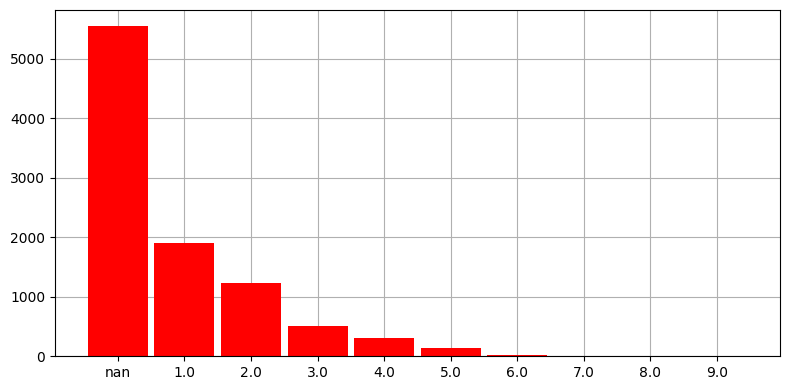

In [144]:
# examine the root orders within this RD <= 1.00 mm subset

freq = subset.F00056.value_counts(dropna=False)
fig, axes = plt.subplots()
fig.set_size_inches(8, 4)
axes.bar(x=freq.index.fillna(0), # without replacing with 0s, NaNs get ignored in x???
         height=freq.values, width=0.9, color="red")
axes.grid()
axes.set_axisbelow(True)
axes.set_xticks(ticks=np.linspace(start=0, stop=freq.size - 1, num=freq.size), labels=freq.index)
plt.tight_layout()
plt.show()

In [145]:
# drop records where root order is > 3 ???
# this is concerning but Luke advised against mixing the two approaches
subset.query(r"F00056 > 3")

,F01286,F01287,F01289,F01290,F00679,F00727,F00709,F00056
14,Acer,saccharum,Sapindaceae,Sapindales,0.220000,70.500000,NaN,4.0
15,Acer,saccharum,Sapindaceae,Sapindales,0.210000,83.100000,NaN,5.0
16,Acer,saccharum,Sapindaceae,Sapindales,0.200000,131.100000,NaN,6.0
17,Acer,saccharum,Sapindaceae,Sapindales,0.230000,80.200000,NaN,7.0
20,Fraxinus,americana,Oleaceae,Lamiales,0.210000,108.200000,NaN,4.0
...,...,...,...,...,...,...,...,...
7501,Vitis,vinifera,Vitaceae,Vitales,0.371517,0.480000,NaN,4.0
7502,Vitis,vinifera,Vitaceae,Vitales,0.590948,0.090000,NaN,5.0
7506,Vitis,vinifera,Vitaceae,Vitales,0.600550,0.290000,NaN,4.0
9001,Dacrydium,balansae,Podocarpaceae,Araucariales,0.847640,6.220949,0.526719,4.0


In [146]:
subset.loc[:, BINOMINAL_NAME].drop_duplicates() # that's a good number of species

,F01286,F01287
0,Populus,tremuloides
1,Acer,negundo
2,Juglans,nigra
3,Quercus,rubra
4,Carya,glabra
...,...,...
9591,Sorocea,muriculata
9592,Stachyarrhena,acuminata
9593,Trymatococcus,amazonicus
9594,Zygia,inaequalis


In [147]:
# species record with values for RD, SRL & RTD
subset.dropna(subset=CHOSEN_ROOT_TRAITS).drop_duplicates(subset=BINOMINAL_NAME)

,F01286,F01287,F01289,F01290,F00679,F00727,F00709,F00056
69,Larix,gmelinii,Pinaceae,Pinales,0.319412,32.211568,0.354286,1.0
92,Fraxinus,mandshurica,Oleaceae,Lamiales,0.288462,78.846169,0.231206,1.0
128,Populus,trichocarpa,Salicaceae,Malpighiales,0.142951,447.167648,0.169294,1.0
132,Populus,tremula,Salicaceae,Malpighiales,0.175513,330.424588,0.169294,1.0
358,Cinnamomum,micranthum,Lauraceae,Laurales,0.502558,24.150012,0.209434,1.0
...,...,...,...,...,...,...,...,...
9591,Sorocea,muriculata,Moraceae,Rosales,0.643000,8.540000,0.469000,NaN
9592,Stachyarrhena,acuminata,Rubiaceae,Gentianales,0.376000,20.890000,0.416000,NaN
9593,Trymatococcus,amazonicus,Moraceae,Rosales,0.581000,7.460000,0.531000,NaN
9594,Zygia,inaequalis,Fabaceae,Fabales,0.367000,26.160000,0.362000,NaN


In [148]:
# Luke advised that if a record has SRL & RD, RTD can be back calculated, so we can just filter out NaNs in SRL and RD??
# species records with values for both RD & SRL
subset.dropna(subset=COLLABORATION_GRADIENT_TRAITS).drop_duplicates(subset=BINOMINAL_NAME)

,F01286,F01287,F01289,F01290,F00679,F00727,F00709,F00056
12,Acer,saccharum,Sapindaceae,Sapindales,0.450000,11.500000,NaN,2.0
18,Fraxinus,americana,Oleaceae,Lamiales,0.670000,9.800000,NaN,2.0
23,Viola,pubescens,Violaceae,Malpighiales,0.640000,13.000000,NaN,2.0
27,Hydrophyllum,canadense,Boraginaceae,Boraginales,0.870000,16.200000,NaN,2.0
69,Larix,gmelinii,Pinaceae,Pinales,0.319412,32.211568,0.354286,1.0
...,...,...,...,...,...,...,...,...
9591,Sorocea,muriculata,Moraceae,Rosales,0.643000,8.540000,0.469000,NaN
9592,Stachyarrhena,acuminata,Rubiaceae,Gentianales,0.376000,20.890000,0.416000,NaN
9593,Trymatococcus,amazonicus,Moraceae,Rosales,0.581000,7.460000,0.531000,NaN
9594,Zygia,inaequalis,Fabaceae,Fabales,0.367000,26.160000,0.362000,NaN


In [149]:
subset.dropna(subset=COLLABORATION_GRADIENT_TRAITS).loc[:, BINOMINAL_NAME].drop_duplicates()

,F01286,F01287
12,Acer,saccharum
18,Fraxinus,americana
23,Viola,pubescens
27,Hydrophyllum,canadense
69,Larix,gmelinii
...,...,...
9591,Sorocea,muriculata
9592,Stachyarrhena,acuminata
9593,Trymatococcus,amazonicus
9594,Zygia,inaequalis


In [150]:
# choosing to continue with records that have data for RD & SRL; where RTD, we'll fill those cells using back calculations
subset.dropna(subset=COLLABORATION_GRADIENT_TRAITS, inplace=True)
subset.isna().sum()

F01286       0
F01287       0
F01289       0
F01290       0
F00679       0
F00727       0
F00709    1208
F00056    4564
dtype: int64

According to [Specific root length as an indicator of environmental change](https://www.tandfonline.com/doi/full/10.1080/11263500701626069);   

Specific root length is the length of a unit mass root segment $SRL = \frac{L}{M}$. But, mass is obviously equal to volume multiplied by density; $M = V \times RTD$. So; $SRL = \frac{L}{V \times RTD}$. Assuming a cylindrical shape, the volume `V` of an `L` length root fragment with `RD` diameter is, $V = \pi \times (\frac{RD}{2})^2 \times L$.  
That makes; $SRL = \frac{L}{\pi \times (\frac{RD}{2})^2 \times L \times RTD} = \frac{4}{\pi \times RD^2 \times RTD}$.  
Hence $RTD = \frac{4}{\pi \times RD^2 \times SRL}$.

In [151]:
@njit(fastmath=True)
def back_calculate_rtd(rd: float, srl: float) -> float:
    """
    reference: Ostonen, I. et al. (2007) ‘Specific root length as an indicator of environmental change’,
    Plant Biosystems - An International Journal Dealing with all Aspects of Plant Biology, 141(3), pp. 426–442.
    Available at: https://doi.org/10.1080/11263500701626069.
    """
    return 4.00000 / (np.pi * np.square(rd) * srl)

back_calculate_rtd = np.vectorize(pyfunc=back_calculate_rtd, otypes=[np.float64])

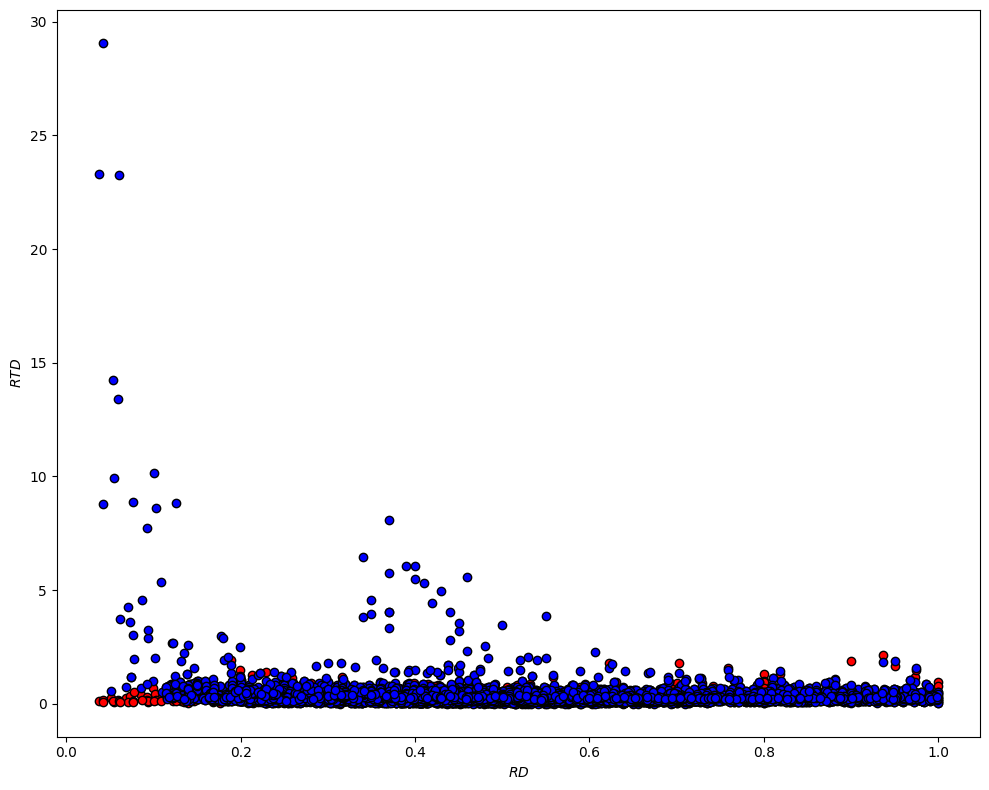

In [157]:
# before we fill the NaNs in RTD with calculated values, check how close our calculations are to actual values where RTD data is available

empirical_rows = subset.query(r"not F00709.isna()").loc[:, CHOSEN_ROOT_TRAITS]

fig, axes = plt.subplots()
fig.set_size_inches(10, 8)
axes.scatter(x=empirical_rows.F00679, y=empirical_rows.F00709, color="red", edgecolor="black")
axes.scatter(x=empirical_rows.F00679, y=back_calculate_rtd(empirical_rows.F00679, empirical_rows.F00727), color="blue", edgecolor="black")
axes.set_xlabel(r"$RD$")
axes.set_ylabel(r"$RTD$")
plt.tight_layout()
plt.show()

In [161]:
# that's concerningly low????
pearsonr(x=empirical_rows.F00709, y=back_calculate_rtd(empirical_rows.F00679, empirical_rows.F00727))

PearsonRResult(statistic=np.float64(0.1940890421715866), pvalue=np.float64(1.8262099893534333e-45))

In [164]:
# abandon the plan to back propagate RTD values and drop the records that have missing RTD values
subset.dropna(subset="F00709", inplace=True)
subset.isna().mean()

F01286    0.000000
F01287    0.000000
F01289    0.000000
F01290    0.000000
F00679    0.000000
F00727    0.000000
F00709    0.000000
F00056    0.721349
dtype: float64

In [165]:
lookup.loc[subset.F01286.unique(), :]

KeyError: "['Austroblechnum', 'Cranfillia', 'Pectinopitys', 'Helesia', 'Tetrapilus', 'Heptapleurum', 'Veronia', 'Prasoxylon', 'Pseudodictamnus', 'Chrysojasminum', 'Hesperostipa', 'Rubroshorea', 'Wurfbainia', 'Andesanthus', 'Imbralyx', 'Alseodaphnopsis', 'Hymenopus', 'Leptobalanus', 'Eumachia'] not in index"

In [ ]:
# we need to manually cross check these genera

# Austroblechnum
# Cranfillia
# Pectinopitys
# Helesia
# Tetrapilus
# Heptapleurum
# Veronia
# Prasoxylon
# Pseudodictamnus
# Chrysojasminum
# Hesperostipa
# Rubroshorea
# Wurfbainia
# Andesanthus
# Imbralyx
# Alseodaphnopsis
# Hymenopus
# Leptobalanus
# Eumachia

In [166]:
# for the genera that the lookup table has taxonomic data for, do the crosschecking
lookup_merged = pd.merge(left=subset.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].query(r"F01286.isin(@lookup.index)").drop_duplicates(),
                         left_on="F01286", right=lookup, right_index=True, how="left").reset_index(drop=True)
lookup_merged

,F01286,F01287,F01289,F01290,family,order,group
0,Larix,gmelinii,Pinaceae,Pinales,Pinaceae,Pinales,Gymnosperms
1,Fraxinus,mandshurica,Oleaceae,Lamiales,Oleaceae,Lamiales,Angiosperms
2,Populus,trichocarpa,Salicaceae,Malpighiales,Salicaceae,Malpighiales,Angiosperms
3,Populus,tremula,Salicaceae,Malpighiales,Salicaceae,Malpighiales,Angiosperms
4,Cinnamomum,micranthum,Lauraceae,Laurales,Lauraceae,Laurales,Angiosperms
...,...,...,...,...,...,...,...
1269,Sorocea,muriculata,Moraceae,Rosales,Moraceae,Rosales,Angiosperms
1270,Stachyarrhena,acuminata,Rubiaceae,Gentianales,Rubiaceae,Gentianales,Angiosperms
1271,Trymatococcus,amazonicus,Moraceae,Rosales,Moraceae,Rosales,Angiosperms
1272,Zygia,inaequalis,Fabaceae,Fabales,Fabaceae,Fabales,Angiosperms


In [167]:
# family level coflicts
lookup_merged.query(r"F01289!=family")

,F01286,F01287,F01289,F01290,family,order,group
32,Hedycarya,arborea,Minimiaceae,Laurales,Monimiaceae,Laurales,Angiosperms
112,Nyssa,sylvatica,Nyssaceae,Cornales,Cornaceae,Cornales,Angiosperms
367,Sambucus,williamsii,Viburnaceae,Dipsacales,Adoxaceae,Dipsacales,Angiosperms
504,Viburnum,dentatum,Viburnaceae,Dipsacales,Adoxaceae,Dipsacales,Angiosperms
531,Apodytes,dimidiata,Metteniusaceae,Metteniusales,Icacinaceae,Icacinales,Angiosperms
631,Viburnum,tinus,Viburnaceae,Dipsacales,Adoxaceae,Dipsacales,Angiosperms
700,Galearia,maingayi,Fabaceae,Fabales,Pandaceae,Malpighiales,Angiosperms
706,Nyssa,aquatica,Nyssaceae,Cornales,Cornaceae,Cornales,Angiosperms
875,Viburnum,stipitatum,Viburnaceae,Dipsacales,Adoxaceae,Dipsacales,Angiosperms
1004,Cephalotaxus,harringtonii,Cephalotaxaceae,Cupressales,Taxaceae,Pinales,Gymnosperms


In [116]:
lookup_merged.query(r"F01289!=family").drop_duplicates()

,F01286,F01287,F01289,F01290,family,order,group
63,Hedycarya,arborea,Minimiaceae,Laurales,Monimiaceae,Laurales,Angiosperms
142,Nyssa,sylvatica,Nyssaceae,Cornales,Cornaceae,Cornales,Angiosperms
434,Sambucus,williamsii,Viburnaceae,Dipsacales,Adoxaceae,Dipsacales,Angiosperms
543,Clinopodium,nepeta,Poaceae,Lamiales,Lamiaceae,Lamiales,Angiosperms
622,Viburnum,dentatum,Viburnaceae,Dipsacales,Adoxaceae,Dipsacales,Angiosperms
638,Sambucus,canadensis,Viburnaceae,Dipsacales,Adoxaceae,Dipsacales,Angiosperms
672,Apodytes,dimidiata,Metteniusaceae,Metteniusales,Icacinaceae,Icacinales,Angiosperms
764,Viburnum,tinus,Viburnaceae,Dipsacales,Adoxaceae,Dipsacales,Angiosperms
833,Galearia,maingayi,Fabaceae,Fabales,Pandaceae,Malpighiales,Angiosperms
844,Nyssa,aquatica,Nyssaceae,Cornales,Cornaceae,Cornales,Angiosperms


In [209]:
# spelling mistakes in FRED are indicated with and asterisk*

# taxa that FRED has correctly

# Nyssa sylvatica - stick to FRED  https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:271953-1#higher-classification
# Sambucus williamsii - stick to FRED  https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:149409-1#higher-classification
# Viburnum dentatum - stick to FRED  https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:326264-2#higher-classification
# Apodytes dimidiata - stick to FRED  https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:434212-1#higher-classification
# Viburnum tinus - stick to FRED  https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:326271-2#higher-classification
# Nyssa aquatica - stick to FRED https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:302695-2#higher-classification
# Viburnum stipitatum - stick to FRED https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77175761-1#higher-classification

# taxa that need intervention

# Hedycarya arborea - *Monimiaceae, Laurales  https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:581882-1#higher-classification
# Galearia maingayi - Pandaceae, Malpighiales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:349146-1#higher-classification
# Cephalotaxus harringtonii - Cephalotaxaceae, Pinales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:261818-1#higher-classification
# Cryptocarya acutifolia - Lauraceae, Laurales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:463781-1#higher-classification
# Barringtonia fusicarpa - Lecythidaceae, Ericales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:104061-1#higher-classification
# Castanopsis indica - Fagaceae, Fagales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:295397-1#higher-classification


In [210]:
# correct the above in the subset and remerge with the lookup table to incorporate the corrections

subset.loc[subset.query(r"F01286=='Hedycarya'").index, "F01289"] = "Monimiaceae"
subset.loc[subset.query(r"F01286=='Hedycarya'").index, "F01290"] = "Laurales"

subset.loc[subset.query(r"F01286=='Galearia'").index, "F01289"] = "Pandaceae"
subset.loc[subset.query(r"F01286=='Galearia'").index, "F01290"] = "Malpighiales"

subset.loc[subset.query(r"F01286=='Cephalotaxus'").index, "F01289"] = "Cephalotaxaceae"
subset.loc[subset.query(r"F01286=='Cephalotaxus'").index, "F01290"] = "Pinales"

subset.loc[subset.query(r"F01286=='Cryptocarya'").index, "F01289"] = "Lauraceae"
subset.loc[subset.query(r"F01286=='Cryptocarya'").index, "F01290"] = "Laurales"

subset.loc[subset.query(r"F01286=='Barringtonia'").index, "F01289"] = "Lecythidaceae"
subset.loc[subset.query(r"F01286=='Barringtonia'").index, "F01290"] = "Ericales"

subset.loc[subset.query(r"F01286=='Castanopsis'").index, "F01289"] = "Fagaceae"
subset.loc[subset.query(r"F01286=='Castanopsis'").index, "F01290"] = "Fagales"

In [211]:
# remerging after corrections, this is necessary since these corrections may have solved some of the order level conflicts
# so before reconciling the order level conflicts, do the remerger
lookup_merged = pd.merge(left=subset.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].query(r"F01286.isin(@lookup.index)").drop_duplicates(),
                         left_on="F01286", right=lookup, right_index=True, how="left").reset_index(drop=True)

In [212]:
# order level conflicts

# with pd.option_context("display.max_rows", 100, "display.max_columns", 10):
#     print(lookup_merged.query(r"F01290!=order").drop_duplicates())

lookup_merged.query(r"F01290!=order").drop_duplicates()

# even though our FRED subset has heaps of order level conflicts with the lookup table, U.PhyloMaker only expects the following columns:
# species, genus, family, species.relative, genus.relative
# don't waste time reconciling the orders :)

,F01286,F01287,F01289,F01290,family,order,group
15,Asplenium,bulbiferum,Aspleniaceae,Polypodiales,Aspleniaceae,Eupolypod II,Pteridophytes
18,Lomaria,discolor,Blechnaceae,Polypodiales,Blechnaceae,Eupolypod II,Pteridophytes
19,Parablechnum,novae-zelandiae,Blechnaceae,Polypodiales,Blechnaceae,Eupolypod II,Pteridophytes
20,Parablechnum,procerum,Blechnaceae,Polypodiales,Blechnaceae,Eupolypod II,Pteridophytes
28,Dacrydium,cupressinum,Podocarpaceae,Araucariales,Podocarpaceae,Pinales,Gymnosperms
...,...,...,...,...,...,...,...
1014,Dacrydium,balansae,Podocarpaceae,Araucariales,Podocarpaceae,Pinales,Gymnosperms
1015,Nageia,nagi,Podocarpaceae,Araucariales,Podocarpaceae,Pinales,Gymnosperms
1019,Chamaecyparis,pisifera,Cupressaceae,Cupressales,Cupressaceae,Pinales,Gymnosperms
1020,Ephedra,distachya,Ephedraceae,Ephedrales,Ephedraceae,Gnetales,Gymnosperms


In [117]:
# now, examine the genera that are missing in the lookup table
subset.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].query(r"not F01286.isin(@lookup.index)").drop_duplicates().sort_values(by=BINOMINAL_NAME)

,F01286,F01287,F01289,F01290
9264,Alseodaphnopsis,andersonii,Lauraceae,Laurales
8172,Andesanthus,lepidotus,Melastomataceae,Myrtales
483,Austroblechnum,lanceolatum,Blechnaceae,Polypodiales
2106,Buchozia,japonica,Rubiaceae,Gentianales
5589,Chrysojasminum,fruticans,Oleaceae,Lamiales
485,Cranfillia,fluviatilis,Blechnaceae,Polypodiales
9493,Eumachia,astrellantha,Rubiaceae,Gentianales
9494,Eumachia,podocephala,Rubiaceae,Gentianales
952,Helesia,tetraptera,Styracaceae,Ericales
7803,Heptapleurum,heptaphyllum,Araliaceae,Apiales


In [ ]:
# Alseodaphnopsis - okay https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77165678-1#higher-classification
# Andesanthus - okay https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77205900-1#higher-classification
# Austroblechnum - synonym of Blechnum chambersii - Aspleniaceae, Polypodiales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:53460-3#higher-classification
# Chrysojasminum - okay https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77144221-1#higher-classification
# Cranfillia - synonym of Blechnum fluviatile - Aspleniaceae, Polypodiales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:17058940-1#higher-classification
# Eumachia - okay https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77154315-1#higher-classification
# Helesia tetraptera - correct the spelling error in FRED - Halesia tetraptera - synonym of Halesia carolina https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:319532-2#higher-classification
# 

In [118]:
# now, cross check if any genera are classified under multiple families
np.where(np.array([subset.query(r"F01286==@g").loc[:, "F01289"].unique().size for g in subset.F01286.unique()]) > 1)

(array([ 20, 104, 126, 156]),)